In [1]:
from scipy.optimize import curve_fit

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import math

data = pd.read_csv("/Users/roychen/Desktop/Module-2-Chen_fink/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)

r0 Range: [2.22382696] - [3.51110983]


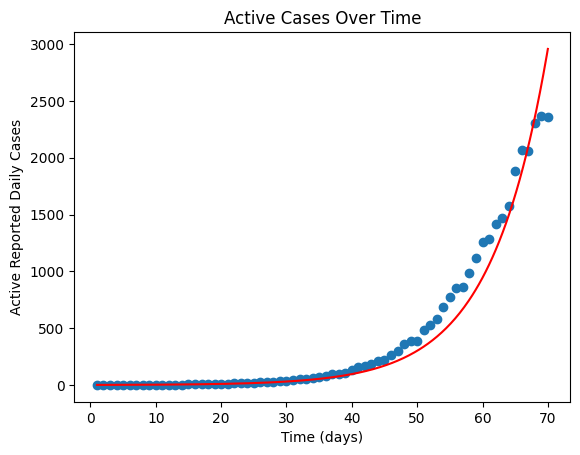

In [ ]:
# We have day number, date, and active cases. We can use the day number and active cases to fit an exponential growth curve to estimate R0.
# Let's define the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

days = []
active_cases = []

for day in data['day']:
    days.append(day)

for case in data['active reported daily cases']:
    active_cases.append(case)

# Fit the exponential growth model to the data. 
# We'll use a handy function from scipy called CURVE_FIT that allows us to fit any given function to our data. 
# We will fit the exponential growth function to the active cases data. HINT: Look up the documentation for curve_fit to see how to use it.

opt_r, covariance = curve_fit(exponential_growth, days, active_cases)
# Approximate R0 using this fit
ip_low = 7 #we know that the infectious period is 7-11 days, so we will use those to calculate a range for R0
ip_high = 11

rdprod_low = ip_low * opt_r # finding rD for low and high ends of infectious period
rdprod_high = ip_high * opt_r

low_r0 = math.e ** rdprod_low
high_r0 = math.e ** rdprod_high

print(f"r0 Range: {low_r0} - {high_r0}") 


# Add the fit as a line on top of your scatterplot.

plt.scatter(days, active_cases)
plt.title("Active Cases Over Time")
plt.xlabel("Time (days)")
plt.ylabel("Active Reported Daily Cases")

t_axis = np.linspace(1, max(days), 400) # creates a an array of 400 evenly spaced points between one and the number of days in the csv file
y_axis = exponential_growth(t_axis,opt_r[0])
plt.plot(t_axis, y_axis, color = 'red') #plot a line of the fit on top of the scatterplot

#plt.show()

#1/infectious period, which we know is 7-11 days
gamma_high = 0.143
gamma_low = 0.091 

# 1/incubation period, which we know is 12-18 days
sigma_high = 0.0833
sigma_low = 0.0556
# estimated R0 range * gamma range 
beta_low = 0.211
beta_high = 0.534

sse = 1000
N = 17612
i0 = 1
r0 = 0
e0 = 2
s0 = N - e0 - i0 - r0
def eulers(beta, sigma, gamma, s0, e0, i0, r0, timepoints, N):
    s = [s0]
    e = [e0]
    i = [i0]
    r = [r0]

    for timepoint in range(len(timepoints)):
        dS_dt = -1 * beta * s[timepoint] * i[timepoint] / N # calculate the derivative at the current timepoint based on the equations from class
        s.append(s[timepoint] + dS_dt)

        dE_dt = (beta * s[timepoint] * i[timepoint] / N) - (sigma * e[timepoint])
        e.append(e[timepoint] + dE_dt)

        dI_dt = (sigma * e[timepoint]) - (gamma * i[timepoint])
        i.append(i[timepoint] + dI_dt)

        dR_dt = gamma * i[timepoint]
        r.append(r[timepoint] + dR_dt) 
    
    return s, e, i, r


def optimization():       
    sse = 10000000000000000
    best_b = 0
    best_s = 0
    best_g = 0

    # iterate through every combination of beta, gamma, and sigma, calculating sse for each combo and determining the best parameters 
    for beta in np.arange(beta_low, beta_high, 0.01):
        for sigma in np.arange(sigma_low, sigma_high, 0.01):
            for gamma in np.arange(gamma_low, gamma_high, 0.01):
                s, e, i, r = eulers(beta, sigma, gamma, s0, e0, i0, r0, days, N)
                sse_new = np.sum((np.array(i[:len(data)]) - active_cases)**2)
                #print("placeholder")
                #sse_new = np.sum((i - y_axis)**2)
                if sse_new < sse:
                    sse = sse_new
                    best_b = beta
                    best_s = sigma
                    best_g = gamma
    
    return best_b, best_s, best_g, sse


best_beta, best_ssigma, best_gamma, sse= optimization()





Best beta: 0.5310, Best sigma: 0.0756, Best gamma: 0.0910
Peak infections: 4065 people
Peak occurs on day: 92
That is 23.1% of the population (17612 total)


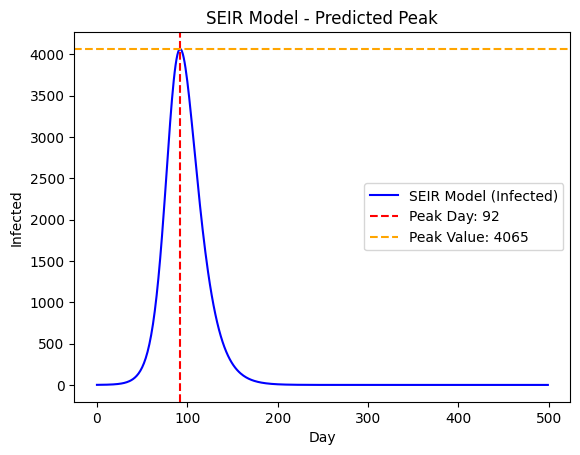

In [4]:
def prediction(best_beta, best_sigma, best_gamma):
    # set up the time points in the furture to run the predicted model. 
    future_days = list(range(500))
    # Run Euler's method far into the future to find the peak
    s, e, i, r = eulers(best_beta, best_sigma, best_gamma, s0, e0, i0, r0, future_days, N)
    # Find the peak number of infected individuals and the day it occurs. sitting i to numbers of days 
    peak_value = max(i)
    peak_day = i.index(peak_value)
    
    print(f"Best beta: {best_beta:.4f}, Best sigma: {best_sigma:.4f}, Best gamma: {best_gamma:.4f}")
    print(f"Peak infections: {peak_value:.0f} people")
    print(f"Peak occurs on day: {peak_day}")
    # Calculate the percentage of the population that is infected at the peak
    print(f"That is {peak_value/N*100:.1f}% of the population ({N} total)")
    
    # Plot the SEIR model's infected curve over time
    # use the infected compartment curve over the 500 predicted days
    plt.figure()
    plt.plot(i[:len(future_days)], label='SEIR Model (Infected)', color='blue')
    plt.axvline(x=peak_day, color='red', linestyle='--', label=f'Peak Day: {peak_day}')
    plt.axhline(y=peak_value, color='orange', linestyle='--', label=f'Peak Value: {peak_value:.0f}')
    plt.title("SEIR Model - Predicted Peak")
    plt.xlabel("Day")
    plt.ylabel("Infected")
    plt.legend()
    plt.show()
    
    return peak_value, peak_day

# Call the function
peak_value, peak_day = prediction(best_beta, best_ssigma, best_gamma)

In [ ]:
# Values from beta, sigma and gamma optimization from UVA nodel to predict Vt outbreak 
best_beta = .531
best_sigma = .0756
best_gamma = .0910 
# population of VT undergraduate student population 
N = 30000
I0 = 1
E0 = 2
R0 = 0
S0 = N - E0 - I0 - R0


t_max = 120
first_t= 70
dt = 1 

# performs one Euler time step update the SEIR epidemic model calculates how many students move between the susceptible, exposed, infectious, and recovered  based on the beta(transmission rate), sigma(incubation rate), and gamma(recovery rate).
def seir_step(S, E, I, R, beta, sigma, gamma, N, dt):
    dS_dt = -beta * S * I / N
    dE_dt = beta * S * I / N - sigma * E
    dI_dt = sigma * E - gamma * I
    dR_dt = gamma * I
    
    S_next = S + dS_dt * dt
    E_next = E + dE_dt * dt
    I_next = I + dI_dt * dt
    R_next = R + dR_dt * dt
    
    return S_next, E_next, I_next, R_next

# runs the seir model to simulate the disease prevenlance over a certain amount of time after start.
def run_seir(beta, sigma, gamma, S0, E0, I0, R0, N, t_max, dt):
    t = np.arange(0, t_max + dt, dt)
    
    S = np.zeros(len(t))
    E = np.zeros(len(t))
    I = np.zeros(len(t))
    R = np.zeros(len(t))
    
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0
    
    for day in range(1, len(t)):
        S[day], E[day], I[day], R[day] = seir_step(
            S[day-1], E[day-1], I[day-1], R[day-1],
            beta, sigma, gamma, N, dt
        )
    
    return t, S, E, I, R

# adds the type of intervention option that could slow down the virus spread and interperate how it would affect the model. 
def run_seir_with_intervention(beta, sigma, gamma, S0, E0, I0, R0, N, t_max, dt, intervention_option):
    t = np.arange(0, t_max + dt, dt)
    S = np.zeros(len(t))
    E = np.zeros(len(t))
    I = np.zeros(len(t))
    R = np.zeros(len(t))
    
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0
    
    current_beta = beta
    current_gamma = gamma
    
    for day in range(1, len(t)):
        
        # Mask mandate, reduce transmission by 40% from day 70, reduce the transmission by 40, (60%) 
        if intervention_option == "masking" and day >= 70:
            current_beta = 0.6 * beta
        
        #Vaccine campaign singletime event on day 70, around 90% effective of 2000 give vaccine
        elif intervention_option == "vaccine_campaign" and day == 70:
            vaccinated_effective = min(2000 * 0.9, S[day-1]) 
            S[day-1] -= vaccinated_effective
            R[day-1] += vaccinated_effective
        
        # Vaccine rollout 1000 on day 70, 80, 90 with 90% efficacy
        elif intervention_option == "vaccine_rollout" and day in [70, 80, 90]:
            vaccinated_effective = min(1000 * 0.9, S[day-1])  
            S[day-1] -= vaccinated_effective
            R[day-1] += vaccinated_effective
        
        #Testing and quarantine reduce the spread of the disease by 2 days starting from day 70 
        elif intervention_option == "testing_quarantine" and day >= 70:
            infectious_period = 1 / gamma
            new_infectious_period = infectious_period - 2
            
            # protect against invalid value
            if new_infectious_period > 0:
                current_gamma = 1 / new_infectious_period
        
        #Closing school for 2 weeks day 70 to day 84 so 20% of normal contacts
        elif intervention_option == "school_closure":
            if 70 <= day < 84:
                current_beta = 0.2 * beta
            else:
                current_beta = beta
        # combination of interventions, mask mandate and school closure
        elif intervention_option == "mask_and_closure":
            if 70 <= day < 84:
                current_beta = 0.6 * 0.2 * beta
            elif day >= 84:
                current_beta = 0.6 * beta
            else:
                current_beta = beta
        #SEIR step 
        S[day], E[day], I[day], R[day] = seir_step(
            S[day-1], E[day-1], I[day-1], R[day-1],
            current_beta, sigma, current_gamma, N, dt
        )
    
    return t, S, E, I, R


def intervention_metrics(I, R, start_day=70, end_day=120):
    peak_infections = np.max(I[start_day:end_day+1])
    total_cases = R[end_day] - R[start_day]
    return peak_infections, total_cases


In [6]:
# run the seir mode with no intervention presented to show each options effectivness. 
t_base, S_base, E_base, I_base, R_base = run_seir(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0, N, t_max, dt
)

# how effective masking would be in reducing the spread of the virus.
t_mask, S_mask, E_mask, I_mask, R_mask = run_seir_with_intervention(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0, N, t_max, dt,
    intervention_option="masking"
)

# how effective Vaccine campaign would be in reducing the spread of the virus.
t_vc, S_vc, E_vc, I_vc, R_vc = run_seir_with_intervention(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0, N, t_max, dt,
    intervention_option="vaccine_campaign"
)

# how effective Vaccine rollout would be in reducing the spread of the virus.
t_vr, S_vr, E_vr, I_vr, R_vr = run_seir_with_intervention(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0, N, t_max, dt,
    intervention_option="vaccine_rollout"
)

# how effective Testing and quarantine would be in reducing the spread of the virus.
t_test, S_test, E_test, I_test, R_test = run_seir_with_intervention(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0, N, t_max, dt,
    intervention_option="testing_quarantine"
)

# how effective would closing school down be in reducing the spread of the virus.
t_close, S_close, E_close, I_close, R_close = run_seir_with_intervention(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0, N, t_max, dt,
    intervention_option="school_closure"
)
# Combined mask mandate the school closure for two weeks with school closure and then mask mandate after school closure is lefted. 
t_combo, S_combo, E_combo, I_combo, R_combo = run_seir_with_intervention(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0, N, t_max, dt,
    intervention_option="mask_and_closure"

)


In [12]:
# Baseline metrics
base_peak, base_cases = intervention_metrics(I_base, R_base)

# Intervention metrics
mask_peak, mask_cases = intervention_metrics(I_mask, R_mask)
vc_peak, vc_cases = intervention_metrics(I_vc, R_vc)
vr_peak, vr_cases = intervention_metrics(I_vr, R_vr)
test_peak, test_cases = intervention_metrics(I_test, R_test)
close_peak, close_cases = intervention_metrics(I_close, R_close)
combo_peak, combo_cases = intervention_metrics(I_combo, R_combo)

print("BASELINE")
print("Peak infections:", base_peak)
print("Cases from day 70-120:", base_cases)
print()

print("MASKING")
print("Peak infections:", mask_peak)
print("Cases prevented:", base_cases - mask_cases)
print()

print("VACCINE CAMPAIGN")
print("Peak infections:", vc_peak)
print("Cases prevented:", base_cases - vc_cases)
print()

print("VACCINE ROLLOUT")
print("Peak infections:", vr_peak)
print("Cases prevented:", base_cases - vr_cases)
print()

print("TESTING + QUARANTINE")
print("Peak infections:", test_peak)
print("Cases prevented:", base_cases - test_cases)
print()

print("SCHOOL CLOSURE")
print("Peak infections:", close_peak)
print("Cases prevented:", base_cases - close_cases)

print("MASKING + SCHOOL CLOSURE")
print("Peak infections:", combo_peak)
print("Cases prevented:", base_cases - combo_cases)
print()

BASELINE
Peak infections: 6923.963031430891
Cases from day 70-120: 22875.571229532638

MASKING
Peak infections: 5181.449420341241
Cases prevented: 4191.881155279501

VACCINE CAMPAIGN
Peak infections: 6335.587680782229
Cases prevented: 1590.17151163366

VACCINE ROLLOUT
Peak infections: 6285.010812127273
Cases prevented: 165.89351313051884

TESTING + QUARANTINE
Peak infections: 5623.224222607041
Cases prevented: -232.8866864389638

SCHOOL CLOSURE
Peak infections: 6028.058667713998
Cases prevented: 4773.602694423287
MASKING + SCHOOL CLOSURE
Peak infections: 4283.985069237562
Cases prevented: 9543.73303613028



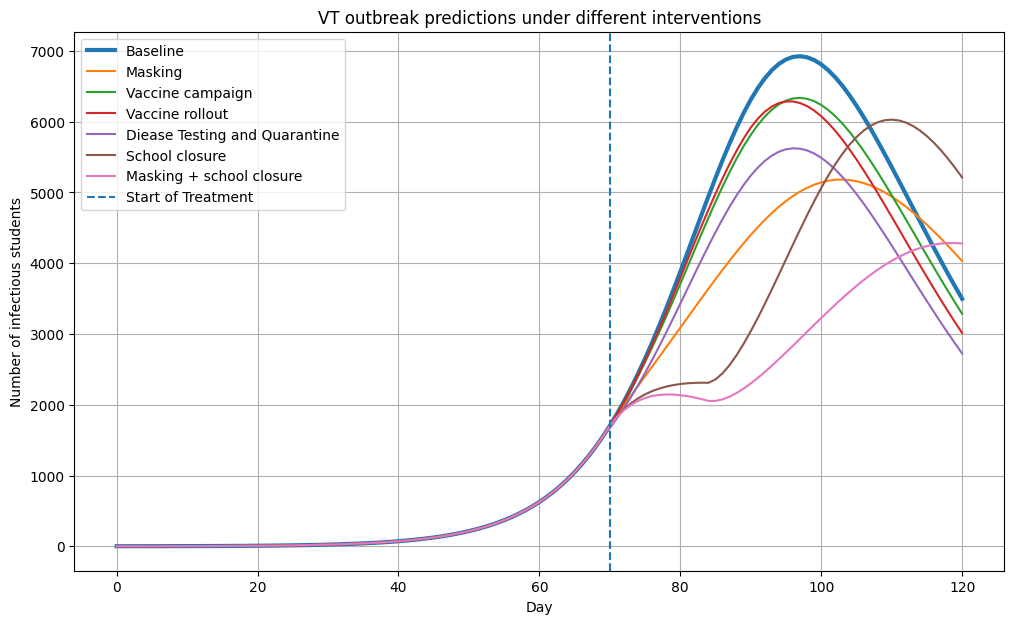

In [13]:
plt.figure(figsize=(12, 7))

plt.plot(t_base, I_base, label="Baseline", linewidth=3)
plt.plot(t_mask, I_mask, label="Masking")
plt.plot(t_vc, I_vc, label="Vaccine campaign")
plt.plot(t_vr, I_vr, label="Vaccine rollout")
plt.plot(t_test, I_test, label="Diease Testing and Quarantine")
plt.plot(t_close, I_close, label="School closure")
plt. plot(t_combo, I_combo, label="Masking + school closure")

plt.axvline(x=70, linestyle="--", label="Start of Treatment")
plt.xlabel("Day")
plt.ylabel("Number of infectious students")
plt.title("VT outbreak predictions under different interventions")
plt.legend()
plt.grid(True)
plt.show()